In [1]:
from google.colab import files
import zipfile
import os

zip_upload = files.upload()

Saving src.zip to src.zip


In [29]:
import sys
# Unzip src.zip
if not os.path.exists('/content/src'):
    with zipfile.ZipFile('src.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

# Add the extracted directory to sys.path
if '/content/' not in sys.path:
    sys.path.insert(0, '/content/')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving delhi_aqi_features.csv to delhi_aqi_features.csv


In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import io

In [4]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
df = pd.read_csv(io.BytesIO(uploaded['delhi_aqi_features.csv']))

In [7]:
target = "pm25"

In [8]:
# Clean up
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)
df = df.ffill().bfill().fillna(0)

In [9]:
print(f"Shape: {df.shape}, Target: {target}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Shape: (43657, 135), Target: pm25
Date range: 0 to 43656


#Prepare Data for PyTorch Forecasting

In [11]:
!pip install pytorch-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 56.9 MB/s eta 0:00:00


In [12]:
import pytorch_forecasting
from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

df_tft = df.reset_index()
df_tft = df_tft.rename(columns={df_tft.columns[0]: "datetime"})
df_tft["time_idx"] = np.arange(len(df_tft))
df_tft["group"] = "delhi"

In [13]:
# Feature classification
known_reals = []
known_candidates = [
    "hour_sin", "hour_cos", "hour_sin2", "hour_cos2",
    "dow_sin", "dow_cos", "month_sin", "month_cos",
    "doy_sin", "doy_cos",
    "is_weekend", "rush_hour", "night_flag",
    "diwali_window", "stubble_season", "winter_flag",
    "solar_proxy",
]
for col in known_candidates:
    if col in df_tft.columns:
        known_reals.append(col)

unknown_reals = [target]
other_candidates = [
    "pm10", "no2", "so2", "co", "o3",
    "temperature", "humidity", "wind_speed", "pressure",
    "stagnation_index", "inversion_proxy", "ventilation_coeff",
    "dewpoint_depression", "fog_risk", "pm25_pm10_ratio",
    "pm25_lag_1", "pm25_lag_24", "pm25_lag_168",
    "pm25_rmean_24", "pm25_rstd_24", "pm25_rmean_168",
    "pm25_diff_1", "pm25_diff_24",
]
for col in other_candidates:
    if col in df_tft.columns:
        unknown_reals.append(col)

unknown_reals = list(dict.fromkeys(unknown_reals))

print(f"Known reals: {len(known_reals)}")
print(f"Unknown reals: {len(unknown_reals)}")

Known reals: 16
Unknown reals: 24


In [16]:
# Split and remove zero-variance columns
MAX_ENCODER_LENGTH = 168
MAX_PREDICTION_LENGTH = 24

n = len(df_tft)
train_cutoff = int(n * 0.70)
val_cutoff = int(n * 0.85)

# Remove zero-variance columns
low_var = []
for col in known_reals + unknown_reals:
    if col != target and col in df_tft.columns:
        if df_tft.loc[:train_cutoff, col].std() < 1e-8:
            low_var.append(col)
if low_var:
    print(f"Removing zero-variance: {low_var}")
    known_reals = [c for c in known_reals if c not in low_var]
    unknown_reals = [c for c in unknown_reals if c not in low_var]

In [17]:
print(f"Train: 0-{train_cutoff}, Val: {train_cutoff}-{val_cutoff}, Test: {val_cutoff}-{n}")

Train: 0-30559, Val: 30559-37108, Test: 37108-43657


In [18]:
# Create Datasets
training = TimeSeriesDataSet(
    df_tft[df_tft.time_idx <= train_cutoff],
    time_idx="time_idx",
    target=target,
    group_ids=["group"],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=["group"],
    time_varying_known_reals=["time_idx"] + known_reals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(
        groups=["group"], transformation="softplus"
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

# Validation — include lookback buffer, NO predict=True
val_start = train_cutoff - MAX_ENCODER_LENGTH
validation = TimeSeriesDataSet.from_dataset(
    training,
    df_tft[(df_tft.time_idx >= val_start) & (df_tft.time_idx <= val_cutoff)],
    stop_randomization=True,
)

# Test — include lookback buffer, NO predict=True
test_start = val_cutoff - MAX_ENCODER_LENGTH
testing = TimeSeriesDataSet.from_dataset(
    training,
    df_tft[df_tft.time_idx >= test_start],
    stop_randomization=True,
)

In [19]:
print(f"\nDatasets: Train={len(training)}, Val={len(validation)}, Test={len(testing)}")


Datasets: Train=30369, Val=6527, Test=6526


In [21]:
# DataLoaders
BATCH_SIZE = 64

train_dataloader = training.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)
test_dataloader = testing.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

x, y = next(iter(train_dataloader))

#Temporal Fusion Transformer

In [22]:
# Configure TFT
from pytorch_forecasting import TemporalFusionTransformer

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=5,
    optimizer="adam",
)

In [23]:
print(f"TFT parameters: {tft.size()/1e3:.1f}k")

TFT parameters: 707.8k


In [24]:
# Train TFT
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

trainer = pl.Trainer(
    max_epochs=80,
    accelerator="auto",
    gradient_clip_val=0.1,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=8, mode="min", verbose=True),
        ModelCheckpoint(
            monitor="val_loss", mode="min",
            filename="best-tft-{epoch}-{val_loss:.4f}", save_top_k=1,
        ),
    ],
    enable_model_summary=True,
    log_every_n_steps=20,
)

trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.9 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 20.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  347 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  133 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 707 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 707 K                                                                                                
Total estimated model params size (MB): 2.831                                                                      
Modules in train mode: 1093                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Metric val_loss improved. New best score: 3.686
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 3.686
INFO: Monitored metric val_loss did not improve in the last 8 records. Best score: 3.686. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 8 records. Best score: 3.686. Signaling Trainer to stop.


In [25]:
# Load Best Model
best_model_path = trainer.checkpoint_callback.best_model_path
print(f"Best model: {best_model_path}")
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

Best model: /content/lightning_logs/version_0/checkpoints/best-tft-epoch=0-val_loss=3.6861.ckpt


#TFT Evaluation

In [26]:
# Generate Predictions
raw_predictions = best_tft.predict(
    test_dataloader, mode="raw", return_x=True,
    trainer_kwargs=dict(accelerator="auto"),
)

point_predictions = best_tft.predict(
    test_dataloader, mode="prediction",
    trainer_kwargs=dict(accelerator="auto"),
)

actuals = torch.cat([y[0] for x, y in iter(test_dataloader)])

tft_preds = point_predictions.cpu().numpy()
tft_actuals = actuals.cpu().numpy()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

In [27]:
print(f"Predictions: {tft_preds.shape}, Actuals: {tft_actuals.shape}")

Predictions: (6526, 24), Actuals: (6526, 24)


In [31]:
# Metrics
from src.evaluation.metrics import calculate_metrics

tft_1step = calculate_metrics(tft_actuals[:, 0], tft_preds[:, 0])

horizon_results = []
for h in range(MAX_PREDICTION_LENGTH):
    m = calculate_metrics(tft_actuals[:, h], tft_preds[:, h])
    m["horizon"] = h + 1
    horizon_results.append(m)

horizon_df = pd.DataFrame(horizon_results).set_index("horizon")
avg_mae = horizon_df["MAE"].mean()
avg_mape = horizon_df["MAPE"].mean()

In [32]:
print(f"TFT Results:")
print(f"  1-Step:  MAE = {tft_1step['MAE']}, MAPE = {tft_1step['MAPE']}%")
print(f"  24h Avg: MAE = {avg_mae:.2f}, MAPE = {avg_mape:.2f}%")
print(f"\nPer-horizon:")
print(horizon_df.to_string())

TFT Results:
  1-Step:  MAE = 7.1, MAPE = 25.8%
  24h Avg: MAE = 7.09, MAPE = 25.55%

Per-horizon:
          MAE  RMSE   MAPE    MASE
horizon                           
1        7.10  8.94  25.80  0.7113
2        7.10  8.94  25.67  0.7111
3        7.10  8.94  25.61  0.7107
4        7.10  8.94  25.59  0.7110
5        7.09  8.94  25.58  0.7108
6        7.09  8.94  25.58  0.7108
7        7.09  8.94  25.58  0.7110
8        7.09  8.94  25.58  0.7111
9        7.09  8.93  25.57  0.7112
10       7.09  8.93  25.56  0.7111
11       7.09  8.93  25.56  0.7111
12       7.09  8.93  25.55  0.7112
13       7.09  8.93  25.54  0.7113
14       7.09  8.93  25.54  0.7111
15       7.09  8.93  25.53  0.7110
16       7.09  8.93  25.52  0.7111
17       7.09  8.93  25.51  0.7109
18       7.09  8.93  25.51  0.7111
19       7.09  8.94  25.50  0.7110
20       7.09  8.94  25.49  0.7107
21       7.09  8.94  25.49  0.7109
22       7.09  8.93  25.48  0.7107
23       7.09  8.93  25.47  0.7107
24       7.09  8.93  25.47

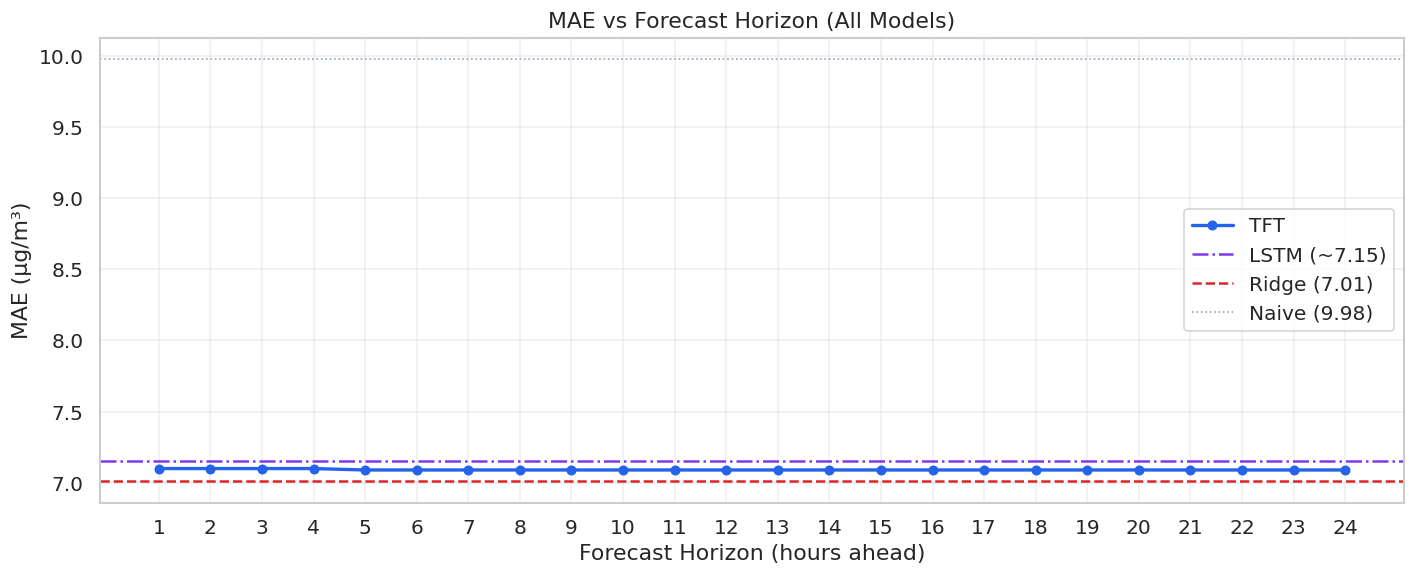

In [33]:
# Horizon Comparison Plot
fig, ax = plt.subplots(figsize=(12, 5))

tft_maes = horizon_df["MAE"].values
ax.plot(range(1, 25), tft_maes, "o-", color="#2563EB", linewidth=2,
        markersize=5, label="TFT")
ax.axhline(y=7.15, color="#7C3AED", linestyle="-.", linewidth=1.5,
           label="LSTM (~7.15)")
ax.axhline(y=7.01, color="#DC2626", linestyle="--", linewidth=1.5,
           label="Ridge (7.01)")
ax.axhline(y=9.98, color="#94A3B8", linestyle=":", linewidth=1,
           label="Naive (9.98)")

ax.set_xlabel("Forecast Horizon (hours ahead)")
ax.set_ylabel("MAE (µg/m³)")
ax.set_title("MAE vs Forecast Horizon (All Models)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 25))
plt.tight_layout()
plt.show()

#TFT Interpretability

In [37]:
# Variable Importance
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")

# Encoder variables
print("Encoder Variable Importance (past inputs):")
enc_vars = best_tft.encoder_variables
enc_imp = interpretation["encoder_variables"]
for name, imp in sorted(zip(enc_vars, enc_imp), key=lambda x: -x[1])[:15]:
    print(f"  {name:35s} {float(imp):.4f}")

print("\nDecoder Variable Importance (future known inputs):")
dec_vars = best_tft.decoder_variables
dec_imp = interpretation["decoder_variables"]
for name, imp in sorted(zip(dec_vars, dec_imp), key=lambda x: -x[1])[:10]:
    print(f"  {name:35s} {float(imp):.4f}")

Encoder Variable Importance (past inputs):
  pm25_rmean_24                       2726.0923
  doy_cos                             316.5481
  wind_speed                          253.6609
  temperature                         181.3773
  so2                                 166.6322
  dow_sin                             165.1724
  winter_flag                         164.8494
  pm25_lag_168                        148.6404
  month_cos                           144.2659
  pm25                                136.8337
  pressure                            132.0519
  relative_time_idx                   109.2268
  no2                                 100.3152
  pm25_lag_1                          96.5596
  dow_cos                             89.0851

Decoder Variable Importance (future known inputs):
  hour_sin                            1773.3717
  diwali_window                       480.0401
  doy_sin                             467.6276
  relative_time_idx                   465.2558
  doy_cos   

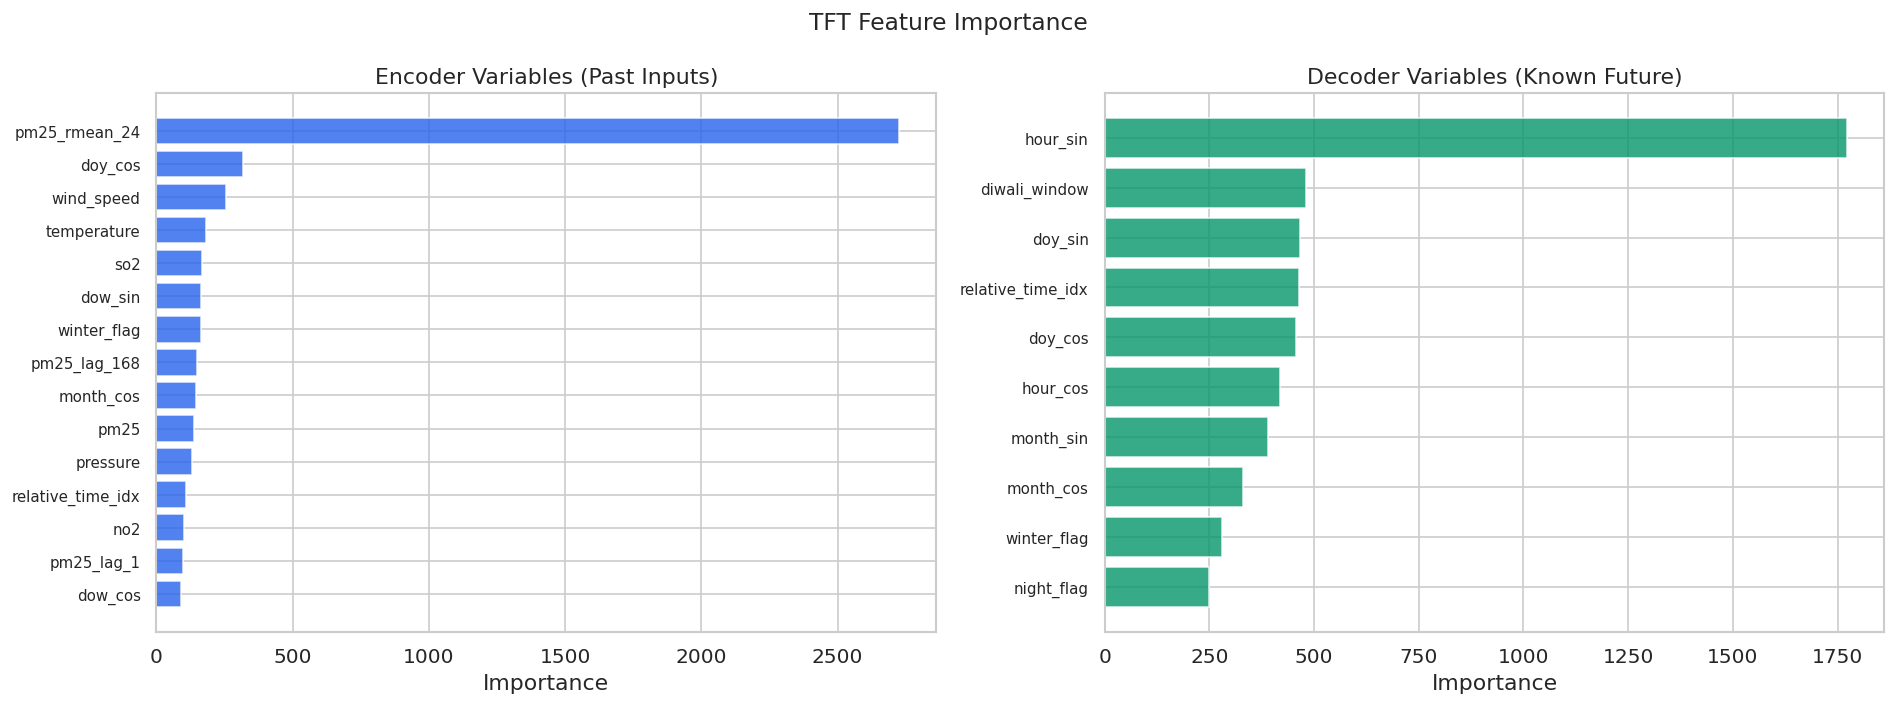

In [38]:
# Variable Importance Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Encoder
top_n = 15
enc_sorted = sorted(zip(enc_vars, enc_imp.cpu().numpy()), key=lambda x: -x[1])[:top_n]
names, vals = zip(*enc_sorted)
axes[0].barh(range(len(names)), vals, color="#2563EB", alpha=0.8)
axes[0].set_yticks(range(len(names)))
axes[0].set_yticklabels(names, fontsize=9)
axes[0].set_xlabel("Importance")
axes[0].set_title("Encoder Variables (Past Inputs)")
axes[0].invert_yaxis()

# Decoder
dec_sorted = sorted(zip(dec_vars, dec_imp.cpu().numpy()), key=lambda x: -x[1])[:10]
names_d, vals_d = zip(*dec_sorted)
axes[1].barh(range(len(names_d)), vals_d, color="#059669", alpha=0.8)
axes[1].set_yticks(range(len(names_d)))
axes[1].set_yticklabels(names_d, fontsize=9)
axes[1].set_xlabel("Importance")
axes[1].set_title("Decoder Variables (Known Future)")
axes[1].invert_yaxis()

plt.suptitle("TFT Feature Importance", fontsize=14)
plt.tight_layout()
plt.show()

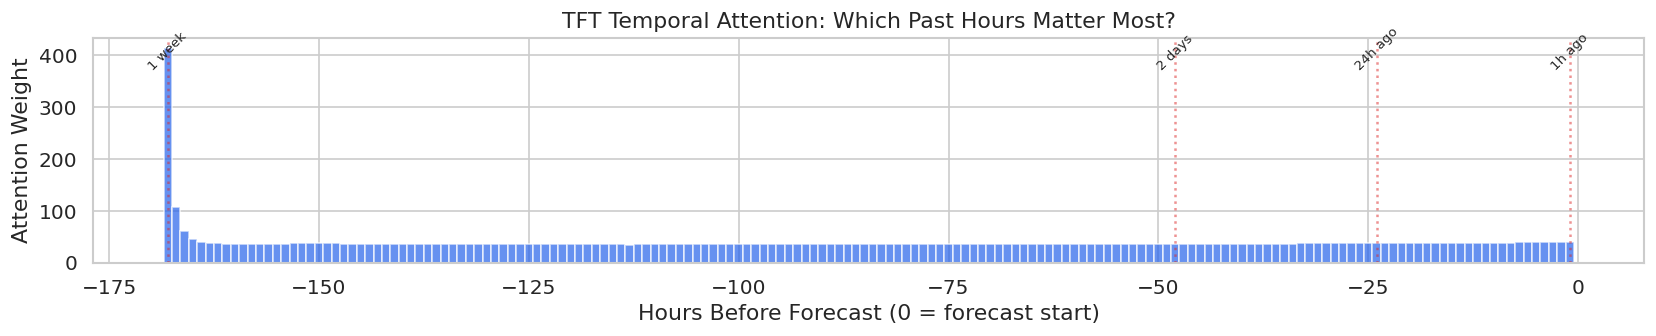

In [39]:
# Attention Weights
fig, ax = plt.subplots(figsize=(14, 3))

attn = interpretation["attention"].cpu().numpy()
hours_back = range(-len(attn), 0)

ax.bar(hours_back, attn, color="#2563EB", alpha=0.7, width=1.0)
ax.set_xlabel("Hours Before Forecast (0 = forecast start)")
ax.set_ylabel("Attention Weight")
ax.set_title("TFT Temporal Attention: Which Past Hours Matter Most?")

for lag, label in [(-1, "1h ago"), (-24, "24h ago"), (-48, "2 days"), (-168, "1 week")]:
    if lag >= -len(attn):
        ax.axvline(lag, color="#DC2626", linestyle=":", alpha=0.5)
        ax.text(lag, max(attn) * 0.9, label, ha="center", fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

#Probabilistic Forecasts

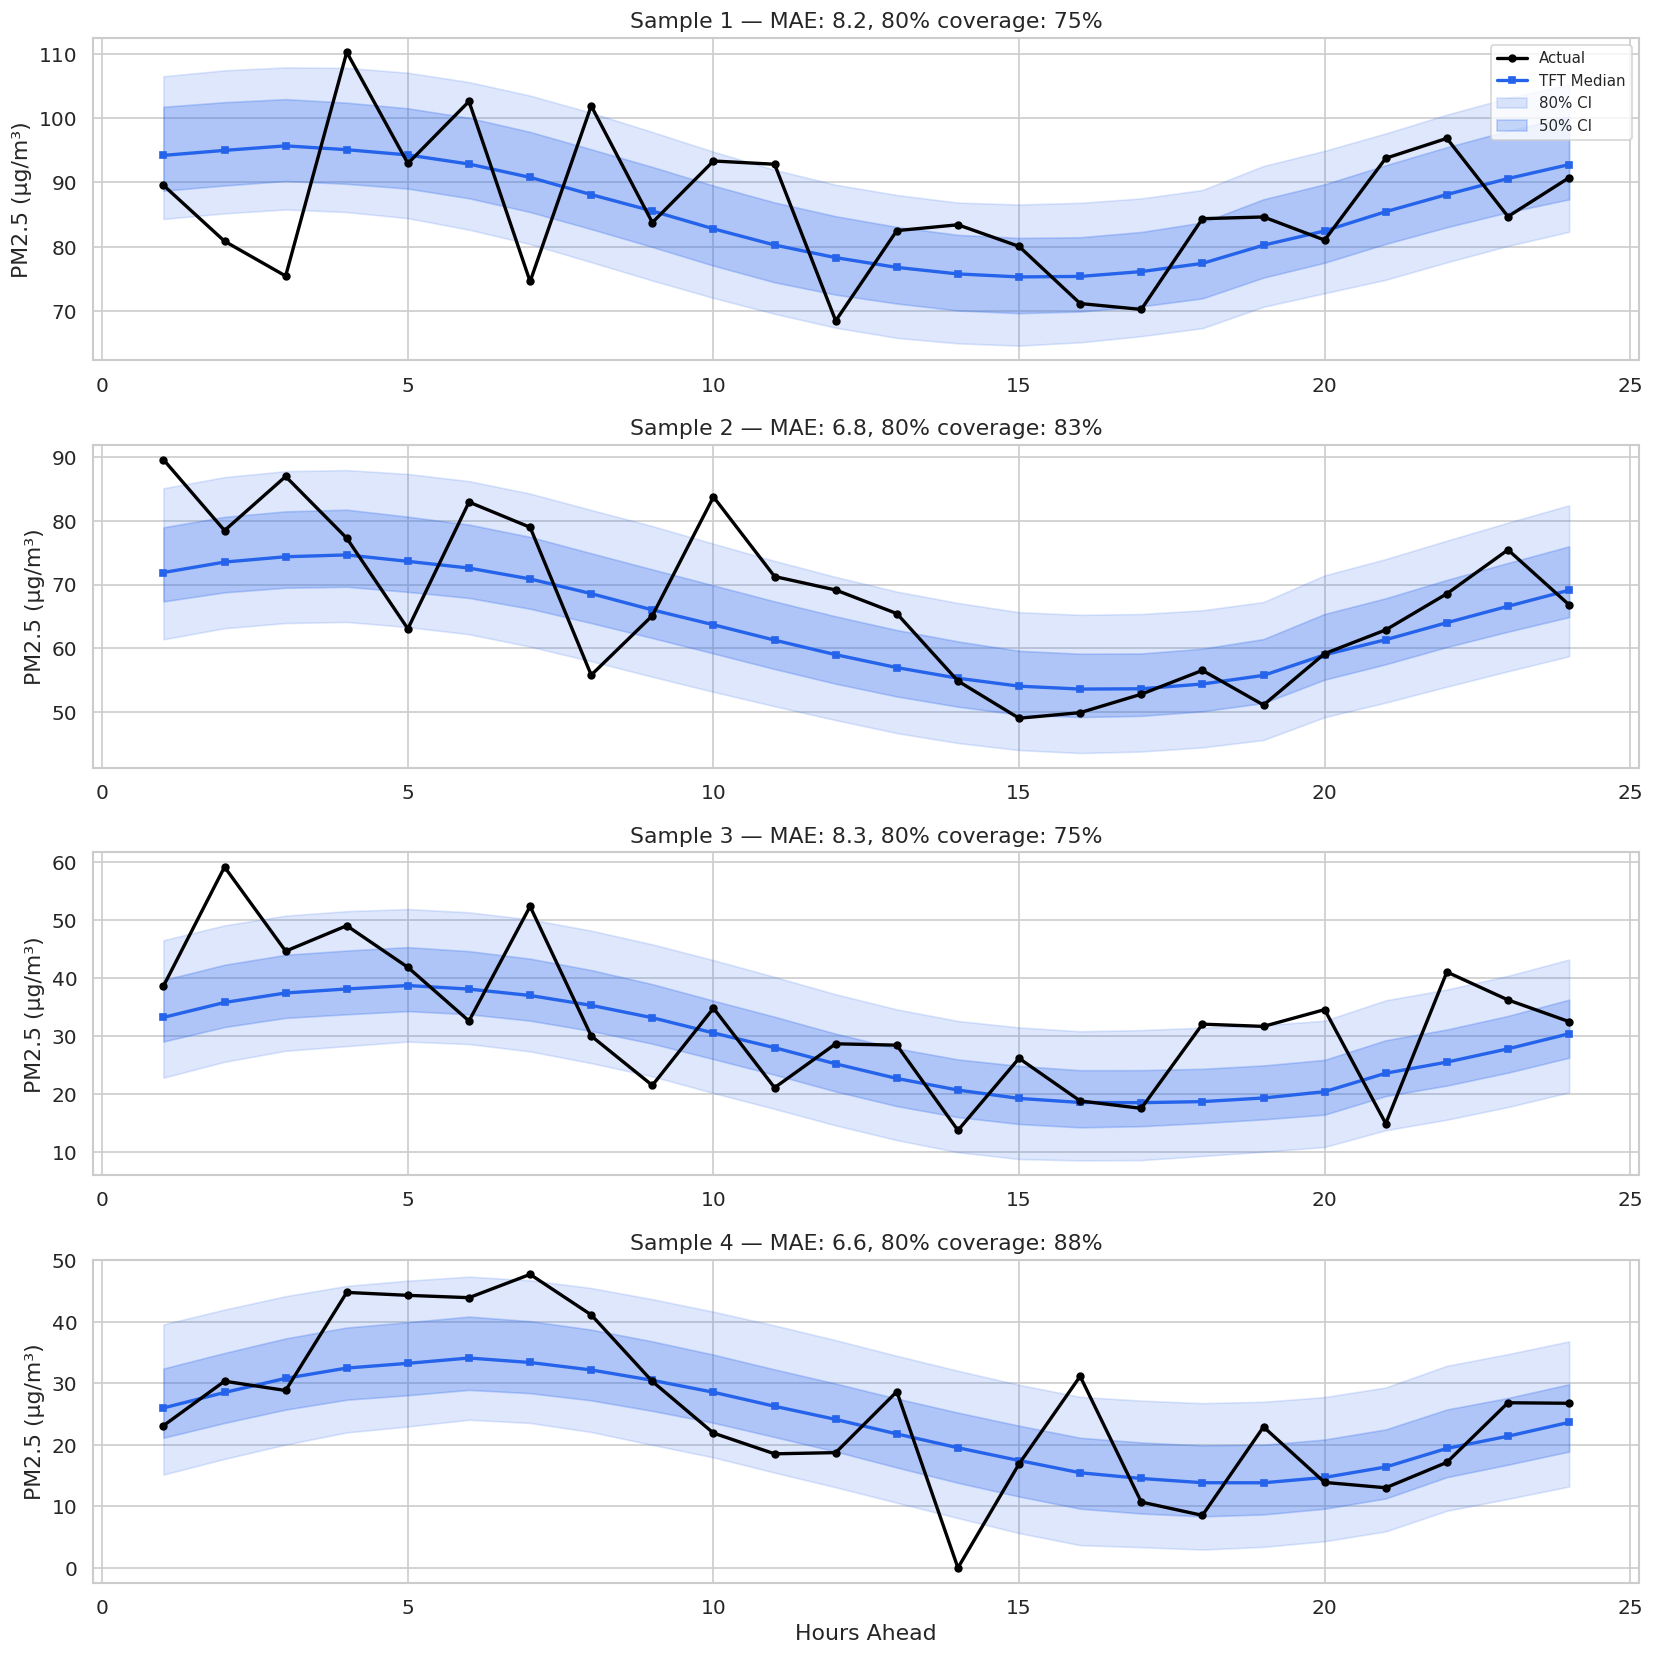

In [46]:
# Quantile Forecast Plots
q_all = raw_predictions.output.prediction.cpu().numpy()

n_plots = 4
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3.5 * n_plots))

for i in range(n_plots):
    ax = axes[i]
    idx = i * (len(tft_actuals) // n_plots)
    hours = range(1, MAX_PREDICTION_LENGTH + 1)
    actual = tft_actuals[idx]
    quantiles = q_all[idx]  # (24, 7)

    median = quantiles[:, 3]
    q10, q90 = quantiles[:, 1], quantiles[:, 5]
    q25, q75 = quantiles[:, 2], quantiles[:, 4]

    ax.plot(hours, actual, "o-", color="#000000", linewidth=2, markersize=4,
            label="Actual", zorder=5)
    ax.plot(hours, median, "s-", color="#2563EB", linewidth=2, markersize=4,
            label="TFT Median")
    ax.fill_between(hours, q10, q90, alpha=0.15, color="#2563EB", label="80% CI")
    ax.fill_between(hours, q25, q75, alpha=0.25, color="#2563EB", label="50% CI")

    mae_i = np.mean(np.abs(actual - median))
    coverage = np.mean((actual >= q10) & (actual <= q90)) * 100
    ax.set_title(f"Sample {i+1} — MAE: {mae_i:.1f}, 80% coverage: {coverage:.0f}%")
    ax.set_ylabel("PM2.5 (µg/m³)")
    if i == 0:
        ax.legend(loc="upper right", fontsize=9)

axes[-1].set_xlabel("Hours Ahead")
plt.tight_layout()
plt.show()

In [49]:
# Calibration Check
q_all = raw_predictions.output.prediction.cpu().numpy()

print("Quantile Calibration:")
for qi, qname, expected in [(0,"2%",2), (1,"10%",10), (2,"25%",25),
                              (4,"75%",75), (5,"90%",90), (6,"98%",98)]:
    below = (tft_actuals < q_all[:, :, qi]).mean() * 100
    print(f"  Below {qname}: {below:.1f}% (expected ~{expected}%)")

coverage_80 = ((tft_actuals >= q_all[:, :, 1]) &
               (tft_actuals <= q_all[:, :, 5])).mean() * 100
print(f"\n  80% interval coverage: {coverage_80:.1f}% (target ~80%)")

Quantile Calibration:
  Below 2%: 2.6% (expected ~2%)
  Below 10%: 9.2% (expected ~10%)
  Below 25%: 23.9% (expected ~25%)
  Below 75%: 72.0% (expected ~75%)
  Below 90%: 90.1% (expected ~90%)
  Below 98%: 97.9% (expected ~98%)

  80% interval coverage: 80.9% (target ~80%)


#N-BEATS

In [52]:
# Train N-BEATS
from pytorch_forecasting import NBeats

nbeats_training = TimeSeriesDataSet(
    df_tft[df_tft.time_idx <= train_cutoff],
    time_idx="time_idx",
    target=target,
    group_ids=["group"],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    time_varying_unknown_reals=[target],
    target_normalizer=GroupNormalizer(groups=["group"], transformation="softplus"),
    allow_missing_timesteps=True,
)

nb_val_start = train_cutoff - MAX_ENCODER_LENGTH
nbeats_validation = TimeSeriesDataSet.from_dataset(
    nbeats_training,
    df_tft[(df_tft.time_idx >= nb_val_start) & (df_tft.time_idx <= val_cutoff)],
    stop_randomization=True,
)

nb_test_start = val_cutoff - MAX_ENCODER_LENGTH
nbeats_testing = TimeSeriesDataSet.from_dataset(
    nbeats_training,
    df_tft[df_tft.time_idx >= nb_test_start],
    stop_randomization=True,
)

nb_train_dl = nbeats_training.to_dataloader(train=True, batch_size=64, num_workers=0)
nb_val_dl = nbeats_validation.to_dataloader(train=False, batch_size=64, num_workers=0)
nb_test_dl = nbeats_testing.to_dataloader(train=False, batch_size=64, num_workers=0)

nbeats = NBeats.from_dataset(
    nbeats_training,
    learning_rate=0.001,
    widths=[256, 2048],
    backcast_loss_ratio=1.0,
)

trainer_nb = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    gradient_clip_val=0.5,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=8, mode="min", verbose=True),
        ModelCheckpoint(monitor="val_loss", mode="min",
                        filename="best-nbeats-{epoch}-{val_loss:.4f}"),
    ],
    log_every_n_steps=20,
)

trainer_nb.fit(nbeats, train_dataloaders=nb_train_dl, val_dataloaders=nb_val_dl)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss            │ MASE       │      0 │ train │     0 │
│ 1 │ logging_metrics │ ModuleList │      0 │ train │     0 │
│ 2 │ net_blocks      │ ModuleList │ 26.9 M │ train │     0 │
└───┴─────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 26.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 26.9 M                                                                                               
Total estimated model params size (MB): 107.563                                                                    
Modules in train mode: 86                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Metric val_loss improved. New best score: 0.713
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 0.713
INFO: Metric val_loss improved by 0.006 >= min_delta = 0.0. New best score: 0.707
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.006 >= min_delta = 0.0. New best score: 0.707
INFO: Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.705
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.705
INFO: Monitored metric val_loss did not improve in the last 8 records. Best score: 0.705. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 8 records. Best score: 0.705. Signaling Trainer to stop.


In [56]:
# N-BEATS Evaluation
best_nb = NBeats.load_from_checkpoint(trainer_nb.checkpoint_callback.best_model_path)

nb_preds_raw = best_nb.predict(nb_test_dl, mode="prediction",
                                trainer_kwargs=dict(accelerator="auto"))
nb_actuals_raw = torch.cat([y[0] for x, y in iter(nb_test_dl)])

nb_preds = nb_preds_raw.cpu().numpy()
nb_acts = nb_actuals_raw.cpu().numpy()

nb_1step = calculate_metrics(nb_acts[:, 0], nb_preds[:, 0])
nb_avg = np.mean([calculate_metrics(nb_acts[:, h], nb_preds[:, h])["MAE"]
                   for h in range(MAX_PREDICTION_LENGTH)])

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

In [57]:
print(f"N-BEATS: 1-Step MAE={nb_1step['MAE']}, MAPE={nb_1step['MAPE']}%")
print(f"         24h Avg MAE={nb_avg:.2f}")

N-BEATS: 1-Step MAE=7.12, MAPE=27.2%
         24h Avg MAE=7.10


#Final Comparison

In [61]:
# Summary
print(f"""

                    FINAL MODEL COMPARISON


  Model                  MAE (1-step)  MAPE (1-step)  24h Avg MAE

  Naive Persistence         9.98         35.2%           —
  Seasonal Naive            9.98         35.7%           —
  Moving Avg (48h)          9.53         38.0%           —
  Linear Ridge              7.01         26.4%           —
  LSTM                      7.13         27.3%         7.16
  N-BEATS                   {nb_1step['MAE']:<12} {nb_1step['MAPE']}%{'':<9}{nb_avg:.2f}
  TFT                       {tft_1step['MAE']:<12} {tft_1step['MAPE']}%{'':<9}{avg_mae:.2f}


""")

for name, mae in [("LSTM", 7.13), ("N-BEATS", nb_1step["MAE"]),
                   ("TFT", tft_1step["MAE"])]:
    imp = (1 - mae / 7.01) * 100
    imp_naive = (1 - mae / 9.98) * 100
    print(f"  {name:10s} vs Ridge: {imp:+.1f}% | vs Naive: {imp_naive:+.1f}%")



                    FINAL MODEL COMPARISON


  Model                  MAE (1-step)  MAPE (1-step)  24h Avg MAE
      
  Naive Persistence         9.98         35.2%           —
  Seasonal Naive            9.98         35.7%           —
  Moving Avg (48h)          9.53         38.0%           —
  Linear Ridge              7.01         26.4%           —
  LSTM                      7.13         27.3%         7.16
  N-BEATS                   7.12         27.2%         7.10
  TFT                       7.1          25.8%         7.09



  LSTM       vs Ridge: -1.7% | vs Naive: +28.6%
  N-BEATS    vs Ridge: -1.6% | vs Naive: +28.7%
  TFT        vs Ridge: -1.3% | vs Naive: +28.9%


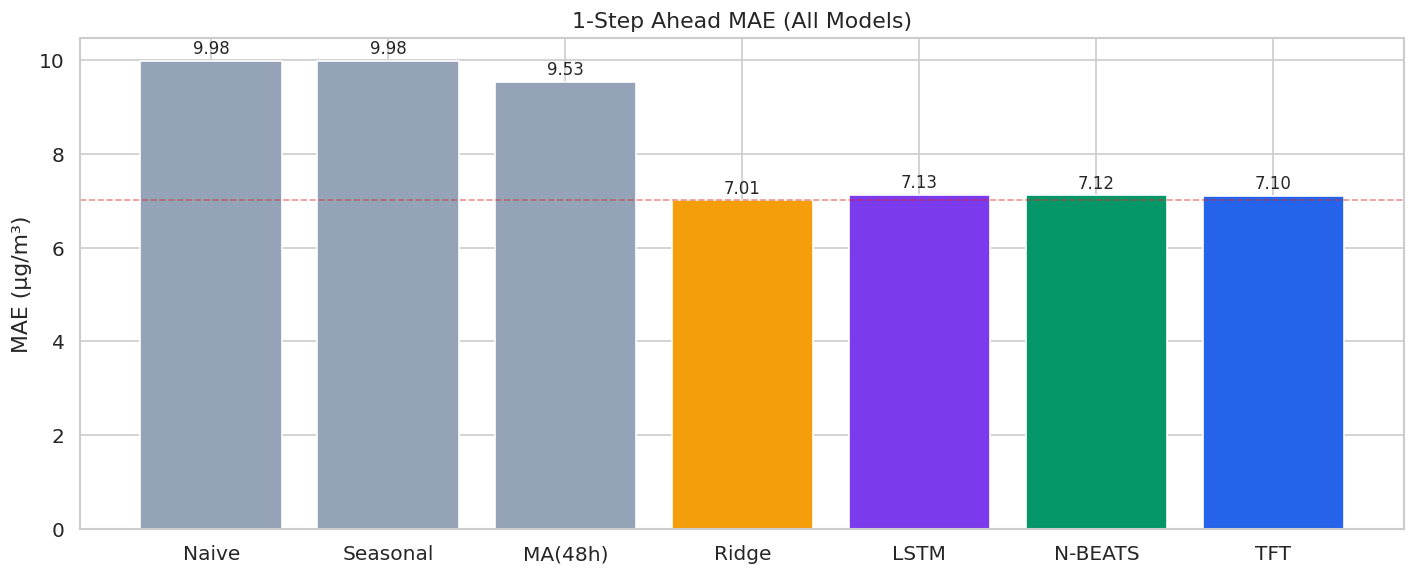

In [60]:
# Final Bar Chart
fig, ax = plt.subplots(figsize=(12, 5))

models = ["Naive", "Seasonal", "MA(48h)", "Ridge", "LSTM", "N-BEATS", "TFT"]
maes = [9.98, 9.98, 9.53, 7.01, 7.13, nb_1step["MAE"], tft_1step["MAE"]]
colors = ["#94A3B8", "#94A3B8", "#94A3B8", "#F59E0B", "#7C3AED", "#059669", "#2563EB"]

bars = ax.bar(models, maes, color=colors)
ax.axhline(y=7.01, color="#DC2626", linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("MAE (µg/m³)")
ax.set_title("1-Step Ahead MAE (All Models)")

for bar, v in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.15, f"{v:.2f}",
            ha="center", fontsize=10)

plt.tight_layout()
plt.show()